# 📡 Notebook 09 — Frequency Domain Forensics (FFT CNN)
Person 3

> Needs `data/faces/` from notebook 02. Can run in parallel with 07 and 08.

In [1]:
# ✅ Cell 1 — Install
!pip install torch torchvision tqdm scikit-learn opencv-python-headless scipy -q

In [2]:
# ✅ Cell 2 — GPU Check
import torch

print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.empty_cache()
    print("\n✅ GPU ready!")
else:
    print("\n⚠️  No GPU detected!")
    print("   Go to: Runtime → Change runtime type → T4 GPU → Save")
    print("   Then: Runtime → Disconnect and delete runtime → Reconnect")
    print("   Then rerun from Cell 1")

CUDA available : True
GPU name       : Tesla T4
GPU memory     : 15.6 GB

✅ GPU ready!


In [3]:
# ✅ Cell 3 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted.")

Mounted at /content/drive
✅ Drive mounted.


In [4]:
# ✅ Cell 4 — Imports & Config
import os, random, numpy as np, cv2, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
from scipy.fft import dct
import warnings
warnings.filterwarnings("ignore")

# ── FIXED: correct BASE_DIR path ──
BASE_DIR  = "/content/drive/MyDrive/Colab Notebooks/deepfake-project"
FACES_DIR = os.path.join(BASE_DIR, "data/faces")
FFT_DIR   = os.path.join(BASE_DIR, "data/frequency_maps")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(FFT_DIR,   exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Force GPU ──
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE   = 224
MAP_SIZE   = 224
BATCH_SIZE = 128   # increased — T4 handles this easily for 1-channel input
EPOCHS     = 15
LR         = 5e-4
SEED       = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Verify faces folder
if os.path.isdir(FACES_DIR):
    total = sum(1 for _ in Path(FACES_DIR).rglob("*.jpg"))
    print(f"✅ Device  : {DEVICE}")
    print(f"✅ Faces   : {total} images found in {FACES_DIR}")
else:
    print(f"❌ FACES_DIR not found: {FACES_DIR}")
    print("   Run notebook 02 first!")

✅ Device  : cuda
✅ Faces   : 7368 images found in /content/drive/MyDrive/Colab Notebooks/deepfake-project/data/faces


In [5]:
# ✅ Cell 5 — FFT Map Function
def compute_frequency_map(img_bgr: np.ndarray, size: int = MAP_SIZE,
                           use_dct: bool = False) -> np.ndarray:
    """
    Convert face image → frequency domain map.
    Returns float32 [size, size] normalised to [0, 1].
    """
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gray  = cv2.resize(gray, (size, size))

    if use_dct:
        freq = dct(dct(gray, axis=0, norm="ortho"), axis=1, norm="ortho")
    else:
        # Centred FFT log-magnitude — this is what detects GAN fingerprints
        f     = np.fft.fft2(gray)
        fshift= np.fft.fftshift(f)
        freq  = 20 * np.log(np.abs(fshift) + 1)

    freq = (freq - freq.min()) / (freq.max() - freq.min() + 1e-8)
    return freq.astype(np.float32)

print("✅ compute_frequency_map() defined.")

✅ compute_frequency_map() defined.


In [6]:
# ✅ Cell 6 — Precompute ALL Frequency Maps (runs once, cached forever)
def precompute_frequency_maps(faces_dir, fft_dir, splits):
    for split in splits:
        in_sub  = os.path.join(faces_dir, split)
        out_sub = os.path.join(fft_dir,   split)
        os.makedirs(out_sub, exist_ok=True)

        if not os.path.isdir(in_sub):
            print(f"[SKIP] {in_sub} — not found"); continue

        jpgs    = list(Path(in_sub).rglob("*.jpg"))
        already = list(Path(out_sub).glob("*.npy"))

        if len(already) >= len(jpgs) * 0.95:
            print(f"✅ {split}: already precomputed ({len(already)} maps) — skipping")
            continue

        print(f"Computing FFT maps: {split} ({len(jpgs)} images)...")
        for jp in tqdm(jpgs):
            out_path = os.path.join(out_sub, jp.stem + ".npy")
            if os.path.exists(out_path):
                continue   # skip already done
            img = cv2.imread(str(jp))
            if img is None: continue
            fmap = compute_frequency_map(img)
            np.save(out_path, fmap)

        total = len(list(Path(out_sub).glob("*.npy")))
        print(f"  ✅ {split}: {total} maps saved")

splits_all = ["fake", "fake_with_audio", "real", "real_with_audio"]
precompute_frequency_maps(FACES_DIR, FFT_DIR, splits_all)

# Summary
total_maps = sum(1 for _ in Path(FFT_DIR).rglob("*.npy"))
print(f"\n✅ Total frequency maps: {total_maps}")

Computing FFT maps: fake (2225 images)...


100%|██████████| 2225/2225 [01:25<00:00, 26.13it/s]


  ✅ fake: 2225 maps saved
Computing FFT maps: fake_with_audio (1454 images)...


100%|██████████| 1454/1454 [00:54<00:00, 26.61it/s]


  ✅ fake_with_audio: 1454 maps saved
Computing FFT maps: real (2079 images)...


100%|██████████| 2079/2079 [01:19<00:00, 26.10it/s]


  ✅ real: 2079 maps saved
Computing FFT maps: real_with_audio (1610 images)...


100%|██████████| 1610/1610 [01:00<00:00, 26.72it/s]


  ✅ real_with_audio: 1610 maps saved

✅ Total frequency maps: 7368


In [7]:
# ✅ Cell 7 — Dataset
class FreqDataset(Dataset):
    def __init__(self, files, labels):
        self.files  = files
        self.labels = labels

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        fmap = np.load(self.files[idx]).astype(np.float32)  # [224, 224]
        fmap = torch.tensor(fmap).unsqueeze(0)               # [1, 224, 224]
        return fmap, torch.tensor(self.labels[idx], dtype=torch.float32)


def load_freq_pairs(fft_dir, splits_labels):
    files, labels = [], []
    for split, lbl in splits_labels:
        d = os.path.join(fft_dir, split)
        if not os.path.isdir(d): continue
        for fp in Path(d).glob("*.npy"):
            files.append(str(fp)); labels.append(lbl)
    return files, labels

all_f, all_l = load_freq_pairs(FFT_DIR, [
    ("fake", 1), ("fake_with_audio", 1),
    ("real", 0), ("real_with_audio", 0)
])

if len(all_f) == 0:
    print("❌ No frequency maps found!")
    print(f"   Check: {FFT_DIR}")
else:
    # Balance classes
    combined = list(zip(all_f, all_l)); random.shuffle(combined)
    all_f, all_l = zip(*combined)
    f0 = [(f,l) for f,l in zip(all_f,all_l) if l==0]
    f1 = [(f,l) for f,l in zip(all_f,all_l) if l==1]
    n  = min(len(f0), len(f1))
    balanced = f0[:n] + f1[:n]; random.shuffle(balanced)
    all_f, all_l = zip(*balanced)

    n_val = int(len(all_f) * 0.15)
    tr_f, tr_l = list(all_f[n_val:]), list(all_l[n_val:])
    va_f, va_l = list(all_f[:n_val]), list(all_l[:n_val])

    # num_workers=0 — avoids Drive multiprocessing errors on Colab
    tr_dl = DataLoader(FreqDataset(tr_f, tr_l),
                       batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    va_dl = DataLoader(FreqDataset(va_f, va_l),
                       batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"✅ Train: {len(tr_f)} | Val: {len(va_f)}")
    print(f"✅ Train batches: {len(tr_dl)}")
    print(f"   Fake: {sum(all_l)} | Real: {len(all_l)-sum(all_l)}")

✅ Train: 6255 | Val: 1103
✅ Train batches: 49
   Fake: 3679 | Real: 3679


In [8]:
# ✅ Cell 8 — FreqCNN Model
class FreqCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                                        # → 112×112
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                        # → 56×56
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                        # → 28×28
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                # → 1×1
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x): return self.net(x).squeeze(1)

model = FreqCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ FreqCNN on {DEVICE}")
print(f"   Parameters: {total_params:,}")

✅ FreqCNN on cuda
   Parameters: 405,313


In [9]:
# ✅ Cell 9 — Training Loop
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
best_auc  = 0.0

print(f"Training on {DEVICE} | {EPOCHS} epochs | batch={BATCH_SIZE}\n")

for epoch in range(1, EPOCHS + 1):
    model.train(); tr_loss = 0
    for fmap, lbl in tqdm(tr_dl, desc=f"Epoch {epoch}/{EPOCHS}"):
        fmap, lbl = fmap.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        out  = model(fmap)
        loss = criterion(out, lbl)
        loss.backward(); optimizer.step()
        tr_loss += loss.item()
    scheduler.step()

    model.eval(); probs, lbls_all = [], []
    with torch.no_grad():
        for fmap, lbl in va_dl:
            p = torch.sigmoid(model(fmap.to(DEVICE))).cpu().numpy()
            probs.extend(p); lbls_all.extend(lbl.numpy())

    auc = roc_auc_score(lbls_all, probs)
    acc = accuracy_score(lbls_all, [p > 0.5 for p in probs])
    print(f"  Epoch {epoch:02d}: loss={tr_loss/len(tr_dl):.4f}"
          f"  val_acc={acc:.4f}  val_auc={auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "freq_model.pth"))
        print(f"  ✔ Saved best model (AUC={auc:.4f})")

print(f"\n✅ Training complete. Best AUC: {best_auc:.4f}")
print(f"✅ Saved → {os.path.join(MODEL_DIR, 'freq_model.pth')}")

Training on cuda | 15 epochs | batch=128



Epoch 1/15: 100%|██████████| 49/49 [00:52<00:00,  1.07s/it]


  Epoch 01: loss=0.6875  val_acc=0.5150  val_auc=0.5672
  ✔ Saved best model (AUC=0.5672)


Epoch 2/15: 100%|██████████| 49/49 [00:37<00:00,  1.29it/s]


  Epoch 02: loss=0.6702  val_acc=0.5413  val_auc=0.6376
  ✔ Saved best model (AUC=0.6376)


...

  Epoch 13: loss=0.5364  val_acc=0.5703  val_auc=0.7434


Epoch 14/15: 100%|██████████| 49/49 [00:37<00:00,  1.31it/s]


  Epoch 14: loss=0.5335  val_acc=0.5630  val_auc=0.7568
  ✔ Saved best model (AUC=0.7568)


Epoch 15/15: 100%|██████████| 49/49 [00:37<00:00,  1.31it/s]


  Epoch 15: loss=0.5107  val_acc=0.6754  val_auc=0.7835
  ✔ Saved best model (AUC=0.7835)

✅ Training complete. Best AUC: 0.7835
✅ Saved → /content/drive/MyDrive/Colab Notebooks/deepfake-project/models/freq_model.pth


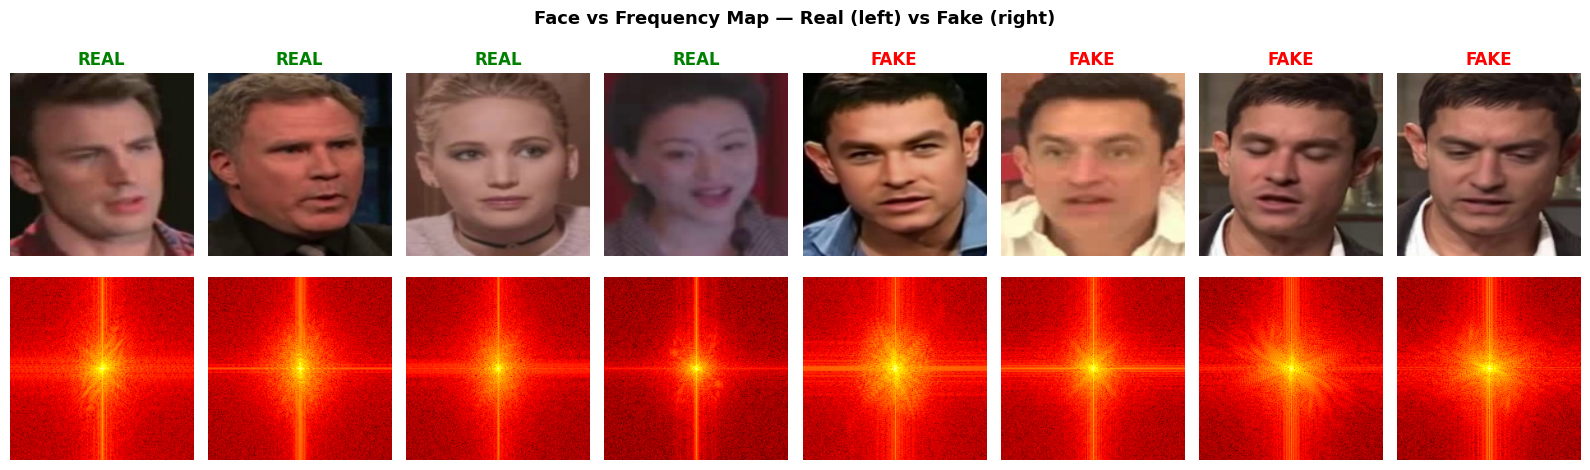

✅ Real FFT maps look smooth | Fake FFT maps show GAN grid patterns


In [10]:
# ✅ Cell 10 — Visualise Real vs Fake Frequency Maps
def show_freq_comparison(n=4):
    fig, axes = plt.subplots(2, n * 2, figsize=(4 * n, 5))

    for col, (split, label_text) in enumerate([("real","REAL"), ("fake","FAKE")]):
        fft_sub  = os.path.join(FFT_DIR, split)
        face_sub = os.path.join(FACES_DIR, split)

        if not os.path.isdir(fft_sub):
            print(f"[SKIP] {fft_sub}"); continue

        npy_files = list(Path(fft_sub).glob("*.npy"))
        if not npy_files: continue
        sample = random.sample(npy_files, min(n, len(npy_files)))

        for i, fp in enumerate(sample):
            ax_face = axes[0, col * n + i]
            ax_freq = axes[1, col * n + i]

            # Face image
            face_path = os.path.join(face_sub, fp.stem + ".jpg")
            if os.path.exists(face_path):
                import cv2
                face = cv2.imread(face_path)
                ax_face.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
            ax_face.set_title(label_text, color="red" if label_text=="FAKE" else "green",
                               fontweight="bold")
            ax_face.axis("off")

            # Frequency map
            fmap = np.load(str(fp))
            ax_freq.imshow(fmap, cmap="hot")
            ax_freq.axis("off")

    axes[0, 0].set_ylabel("Face",      fontsize=11)
    axes[1, 0].set_ylabel("FFT Map",   fontsize=11)
    plt.suptitle("Face vs Frequency Map — Real (left) vs Fake (right)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("✅ Real FFT maps look smooth | Fake FFT maps show GAN grid patterns")

show_freq_comparison()

In [11]:
# ✅ Cell 11 — Final Confirmation
pth_path = os.path.join(MODEL_DIR, "freq_model.pth")
if os.path.exists(pth_path):
    size_mb = os.path.getsize(pth_path) / 1e6
    print(f"✅ freq_model.pth saved ({size_mb:.1f} MB)")
    print(f"   Location: {pth_path}")
    print("\n🎉 Notebook 09 complete!")
    print("   Person 3 can now run notebook 10 (fusion) once ALL .pth files exist:")
    print("   ✅ visual_cnn.pth    (notebook 05)")
    print("   ✅ temporal_lstm.pth (notebook 06)")
    print("   ✅ audio_crnn.pth    (notebook 07)")
    print("   ✅ lipsync_net.pth   (notebook 08)")
    print("   ✅ freq_model.pth    (this notebook)")
else:
    print("❌ freq_model.pth NOT found — check training cell for errors")

✅ freq_model.pth saved (1.6 MB)
   Location: /content/drive/MyDrive/Colab Notebooks/deepfake-project/models/freq_model.pth

🎉 Notebook 09 complete!
   Person 3 can now run notebook 10 (fusion) once ALL .pth files exist:
   ✅ visual_cnn.pth    (notebook 05)
   ✅ temporal_lstm.pth (notebook 06)
   ✅ audio_crnn.pth    (notebook 07)
   ✅ lipsync_net.pth   (notebook 08)
   ✅ freq_model.pth    (this notebook)
